# 🔵 TẦNG 2 — DIAGNOSTIC ANALYTICS
## *"Why did it happen?"* — Tại sao lại như vậy?

> **Mục tiêu:** Phân tích nguyên nhân chênh lệch lương — so sánh nhóm & kiểm định thống kê.  
> **Trả lời:**  
> - ❓ Câu hỏi 3: Có sự chênh lệch lương giữa các nhóm lập trình viên không?

---

## ⚙️ PHẦN 0: IMPORT & CHUẨN BỊ DỮ LIỆU

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import f_oneway, ttest_ind
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize'   : (13, 6),
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')
PALETTE = sns.color_palette('husl', 12)
BLUE  = '#2563EB'
RED   = '#EF4444'
GREEN = '#10B981'
print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


In [12]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────
# Đọc dữ liệu
# ─────────────────────────────────────────────────────────────
df = pd.read_csv('salary_data.csv')

# chuẩn hoá tên cột
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

# xoá duplicate
df = df.drop_duplicates()

# ─────────────────────────────────────────────────────────────
# Tự động tìm cột lương
# ─────────────────────────────────────────────────────────────
sal_kw = [
    'salary',
    'pay',
    'comp',
    'wage',
    'income',
    'ctc',
    'annual'
]

SAL_COL = next(
    (
        c for c in df.columns
        if any(k in c for k in sal_kw)
    ),
    None
)

if SAL_COL is None:
    raise ValueError(
        '❌ Không tìm thấy cột lương'
    )

print(
    f'✅ Cột lương tìm được: {SAL_COL}'
)

# ─────────────────────────────────────────────────────────────
# Làm sạch cột lương
# ─────────────────────────────────────────────────────────────

# ép string
df[SAL_COL] = df[SAL_COL].astype(str)

# lowercase
df[SAL_COL] = df[SAL_COL].str.lower()

# xử lý 120k -> 120000
df[SAL_COL] = df[SAL_COL].str.replace(
    r'(\d+(?:\.\d+)?)k',
    lambda m: str(float(m.group(1)) * 1000),
    regex=True
)

# xoá ký tự đặc biệt
df[SAL_COL] = (
    df[SAL_COL]
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace(r'[^0-9.]', '', regex=True)
    .str.strip()
)

# convert numeric
df[SAL_COL] = pd.to_numeric(
    df[SAL_COL],
    errors='coerce'
)

# xoá NaN
df = df.dropna(
    subset=[SAL_COL]
)

# ép float
df[SAL_COL] = df[SAL_COL].astype(float)

# ─────────────────────────────────────────────────────────────
# Kiểm tra kiểu dữ liệu
# ─────────────────────────────────────────────────────────────
print('\n📌 Kiểu dữ liệu salary:')
print(df[SAL_COL].dtype)

print('\n📌 Kiểu object thực tế:')
print(
    df[SAL_COL]
    .apply(type)
    .value_counts()
)

# ─────────────────────────────────────────────────────────────
# Loại outlier
# ─────────────────────────────────────────────────────────────
q01 = df[SAL_COL].quantile(0.25)
q99 = df[SAL_COL].quantile(0.75)

df = df[
    (df[SAL_COL] >= q01) &
    (df[SAL_COL] <= q99)
]

# ─────────────────────────────────────────────────────────────
# Fill missing values
# ─────────────────────────────────────────────────────────────
for col in df.columns:

    if df[col].isnull().sum() > 0:

        if pd.api.types.is_numeric_dtype(df[col]):

            df[col] = df[col].fillna(
                df[col].median()
            )

        else:

            df[col] = df[col].fillna(
                df[col].mode()[0]
            )

# ─────────────────────────────────────────────────────────────
# Salary variable
# ─────────────────────────────────────────────────────────────
sal = df[SAL_COL]

# ─────────────────────────────────────────────────────────────
# TỰ ĐỘNG TÌM CÁC CỘT PHÂN TÍCH
# ─────────────────────────────────────────────────────────────

def find_col(keywords):

    return next(
        (
            c for c in df.columns
            if any(k in c for k in keywords)
        ),
        None
    )

# Job Role
ROLE_COL = find_col([
    'job_role',
    'job_roles',
    'role',
    'position',
    'title'
])

# Employment Status
STATUS_COL = find_col([
    'employment_status',
    'employment',
    'status',
    'job_type',
    'work_type'
])

# Company Rating
RATING_COL = find_col([
    'rating',
    'company_rating',
    'score'
])

# Quốc gia / địa lý
LOCATION_COL = find_col([
    'country',
    'location',
    'region',
    'city',
    'state'
])

# Company
COMPANY_COL = find_col([
    'company',
    'company_name',
    'employer',
    'organization'
])

# ─────────────────────────────────────────────────────────────
# Thông tin dữ liệu
# ─────────────────────────────────────────────────────────────
print('\n' + '='*65)

print(
    f'✅ Dữ liệu sau xử lý: {df.shape[0]:,} dòng'
)

print(
    f'✅ Salary range: '
    f'${sal.min():,.0f} → ${sal.max():,.0f}'
)

print('\n📌 Cột phân tích tìm được:')

print(f'   Job Role         : {ROLE_COL}')
print(f'   Employment Status: {STATUS_COL}')
print(f'   Company Rating   : {RATING_COL}')
print(f'   Location         : {LOCATION_COL}')
print(f'   Company Name     : {COMPANY_COL}')

print('\n📌 Các cột hiện có trong dataset:')

for i, c in enumerate(df.columns, 1):

    print(f'   {i:>2}. {c}')

print('\n⚠️ Nếu phát hiện sai cột:')
print('Ví dụ:')
print('ROLE_COL = "job_roles"')
print('STATUS_COL = "employment_status"')

print('='*65)

✅ Cột lương tìm được: company_name

📌 Kiểu dữ liệu salary:
float64

📌 Kiểu object thực tế:
company_name
<class 'float'>    412
Name: count, dtype: int64

✅ Dữ liệu sau xử lý: 208 dòng
✅ Salary range: $3 → $24

📌 Cột phân tích tìm được:
   Job Role         : job_title
   Employment Status: employment_status
   Company Rating   : rating
   Location         : location
   Company Name     : company_name

📌 Các cột hiện có trong dataset:
    1. rating
    2. company_name
    3. job_title
    4. salary
    5. salaries_reported
    6. location
    7. employment_status
    8. job_roles

⚠️ Nếu phát hiện sai cột:
Ví dụ:
ROLE_COL = "job_roles"
STATUS_COL = "employment_status"


---
## 📌 PHẦN 1: CHÊNH LỆCH LƯƠNG THEO EMPLOYMENT STATUS


📊 Salary theo Employment Status:

employment_status  count  mean  median  std
       Contractor      4  5.00     4.0 2.71
        Full Time    183  8.31     6.0 6.03
           Intern     21 10.05     8.0 7.67

=== DEBUG SALARY ===
count    208.000000
mean       8.423077
std        6.187399
min        3.000000
25%        3.750000
50%        6.000000
75%       11.000000
max       24.000000
Name: company_name, dtype: float64

=== MEAN BY STATUS ===
  employment_status       mean
0        Contractor   5.000000
1         Full Time   8.311475
2            Intern  10.047619


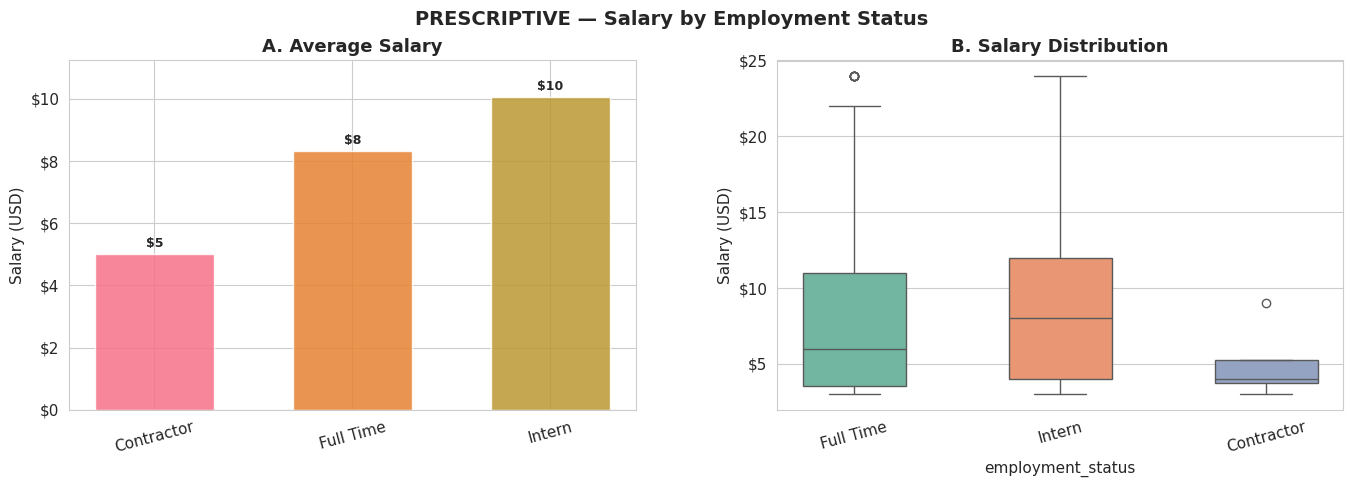


💾 Lưu: pres_02_salary_by_employment_status.png


In [13]:
# ─────────────────────────────────────────────────────────────
# PRESCRIPTIVE — Salary by Employment Status
# ─────────────────────────────────────────────────────────────

STATUS_COL = 'employment_status'

if STATUS_COL in df.columns:

    # ========================================================
    # Statistics
    # ========================================================
    status_stats = (
        df
        .groupby(STATUS_COL)[SAL_COL]
        .agg(['count', 'mean', 'median', 'std'])
        .reset_index()
        .sort_values('mean')
    )

    status_stats['std'] = (
        status_stats['std']
        .fillna(0)
    )

    print('📊 Salary theo Employment Status:\n')

    print(
        status_stats
        .round(2)
        .to_string(index=False)
    )

    # ========================================================
    # Salary Formatter
    # ========================================================
    def salary_formatter(x, pos):
        if x >= 1_000_000:
            return f'${x/1_000_000:.1f}M'
        elif x >= 1_000:
            return f'${x/1_000:.0f}K'
        else:
            return f'${x:,.0f}'

    print("\n=== DEBUG SALARY ===")
    print(df[SAL_COL].describe())

    print("\n=== MEAN BY STATUS ===")
    print(status_stats[[STATUS_COL, 'mean']])

    # ========================================================
    # Figure
    # ========================================================
    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 5)
    )

    fig.suptitle(
        'PRESCRIPTIVE — Salary by Employment Status',
        fontsize=14,
        fontweight='bold',
        y=0.98
    )

    # ========================================================
    # A. BAR CHART
    # ========================================================
    ax = axes[0]

    bars = ax.bar(
        status_stats[STATUS_COL],
        status_stats['mean'],
        color=PALETTE[:len(status_stats)],
        edgecolor='white',
        alpha=0.85,
        width=0.6
    )

    y_max = status_stats['mean'].max()
    label_offset = y_max * 0.015

    for bar, val in zip(bars, status_stats['mean']):

        if val >= 1_000_000:
            label = f'${val/1_000_000:.1f}M'
        elif val >= 1_000:
            label = f'${val/1_000:.1f}K'
        else:
            label = f'${val:,.0f}'

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + label_offset,
            label,
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_ylim(0, y_max * 1.12)

    ax.set_title('A. Average Salary')
    ax.set_ylabel('Salary (USD)')

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(salary_formatter)
    )

    ax.tick_params(axis='x', rotation=15)
    ax.margins(x=0.05)

    # ========================================================
    # B. BOXPLOT
    # ========================================================
    ax = axes[1]

    sns.boxplot(
        data=df,
        x=STATUS_COL,
        y=SAL_COL,
        palette='Set2',
        ax=ax,
        width=0.5
    )

    ax.set_title('B. Salary Distribution')
    ax.set_ylabel('Salary (USD)')
    ax.tick_params(axis='x', rotation=15)

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(salary_formatter)
    )

    ax.margins(x=0.05)

    # ========================================================
    # LAYOUT
    # ========================================================
    plt.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.88,
        bottom=0.18,
        wspace=0.25
    )

    # ========================================================
    # SAVE FIGURE
    # ========================================================
    plt.savefig(
        'pres_02_salary_by_employment_status.png',
        dpi=150,
        bbox_inches='tight',
        pad_inches=0.05
    )

    plt.show()

    print('\n💾 Lưu: pres_02_salary_by_employment_status.png')

else:
    print('❌ Không tìm thấy cột employment_status')

---
## 📌 PHẦN 2: CHÊNH LỆCH LƯƠNG THEO COMPANY RATING


📊 Thống kê Rating:

count    208.00
mean       3.98
std        0.59
min        1.00
25%        3.70
50%        4.00
75%        4.30
max        5.00
Name: rating, dtype: float64

=== DEBUG SALARY ===
count    208.000000
mean       8.423077
std        6.187399
min        3.000000
25%        3.750000
50%        6.000000
75%       11.000000
max       24.000000
Name: company_name, dtype: float64

📈 Correlation giữa Rating và Salary: -0.0260


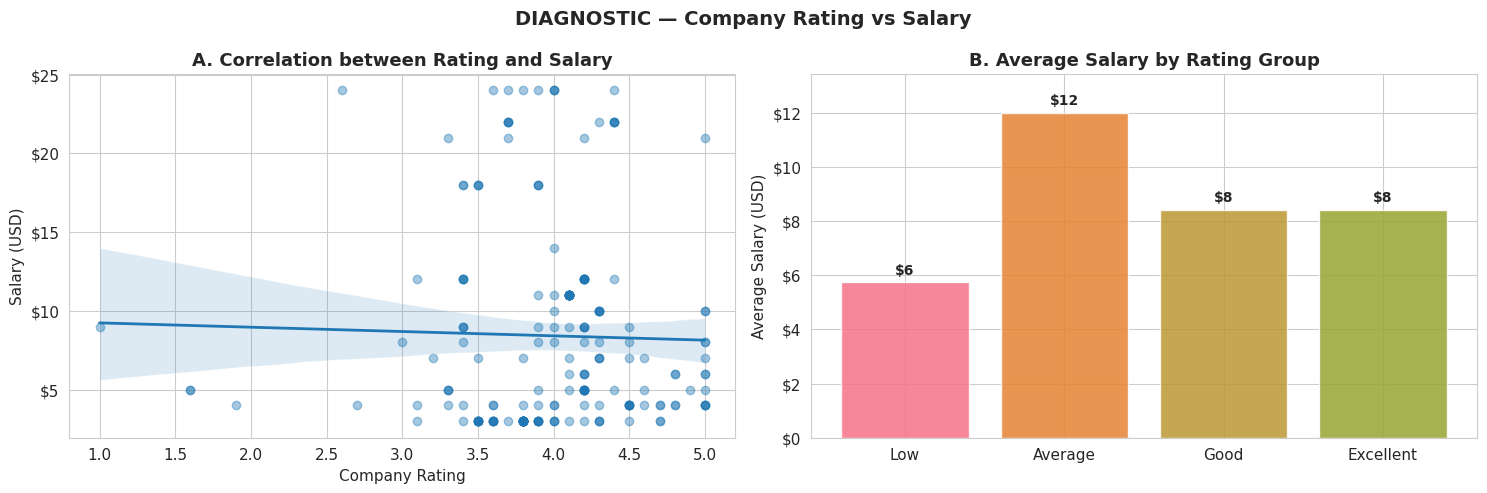


💾 Lưu: diag_02_salary_by_rating.png


In [14]:
# ─────────────────────────────────────────────────────────────
# DIAGNOSTIC — Salary vs Company Rating
# ─────────────────────────────────────────────────────────────

RATING_COL = 'rating'

if RATING_COL in df.columns:

    # ========================================================
    # Làm sạch rating
    # ========================================================
    df[RATING_COL] = pd.to_numeric(
        df[RATING_COL],
        errors='coerce'
    )

    plot_df = df.dropna(
        subset=[RATING_COL, SAL_COL]
    ).copy()

    print('📊 Thống kê Rating:\n')

    print(
        plot_df[RATING_COL]
        .describe()
        .round(2)
    )

    # ========================================================
    # Salary Formatter
    # ========================================================
    def salary_formatter(x, pos):
        if x >= 1_000_000:
            return f'${x/1_000_000:.1f}M'
        elif x >= 1_000:
            return f'${x/1_000:.0f}K'
        else:
            return f'${x:,.0f}'

    print("\n=== DEBUG SALARY ===")
    print(plot_df[SAL_COL].describe())

    # ========================================================
    # Correlation
    # ========================================================
    corr = plot_df[RATING_COL].corr(
        plot_df[SAL_COL]
    )

    print(
        f'\n📈 Correlation giữa Rating và Salary: {corr:.4f}'
    )

    # ========================================================
    # Figure
    # ========================================================
    fig, axes = plt.subplots(
        1, 2,
        figsize=(15, 5)
    )

    fig.suptitle(
        'DIAGNOSTIC — Company Rating vs Salary',
        fontsize=14,
        fontweight='bold'
    )

    # ========================================================
    # A. Scatter Plot
    # ========================================================
    sns.regplot(
        data=plot_df,
        x=RATING_COL,
        y=SAL_COL,
        scatter_kws={'alpha': 0.4},
        line_kws={'linewidth': 2},
        ax=axes[0]
    )

    axes[0].set_title('A. Correlation between Rating and Salary')
    axes[0].set_xlabel('Company Rating')
    axes[0].set_ylabel('Salary (USD)')

    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(salary_formatter)
    )

    # ========================================================
    # B. Rating Groups
    # ========================================================
    plot_df['rating_group'] = pd.cut(
        plot_df[RATING_COL],
        bins=[0, 2, 3, 4, 5],
        labels=['Low', 'Average', 'Good', 'Excellent']
    )

    rating_mean = (
        plot_df
        .groupby('rating_group')[SAL_COL]
        .mean()
    )

    bars = axes[1].bar(
        rating_mean.index.astype(str),
        rating_mean.values,
        color=PALETTE[:len(rating_mean)],
        edgecolor='white',
        alpha=0.85
    )

    y_max = rating_mean.values.max()
    label_offset = y_max * 0.015

    for bar, val in zip(bars, rating_mean.values):

        if val >= 1_000_000:
            label = f'${val/1_000_000:.1f}M'
        elif val >= 1_000:
            label = f'${val/1_000:.1f}K'
        else:
            label = f'${val:,.0f}'

        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            val + label_offset,
            label,
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    axes[1].set_ylim(0, y_max * 1.12)

    axes[1].set_title('B. Average Salary by Rating Group')
    axes[1].set_ylabel('Average Salary (USD)')

    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(salary_formatter)
    )

    # ========================================================
    # SAVE
    # ========================================================
    plt.tight_layout()

    plt.savefig(
        'diag_02_salary_by_rating.png',
        dpi=150,
        bbox_inches='tight',
        pad_inches=0.05
    )

    plt.show()

    print('\n💾 Lưu: diag_02_salary_by_rating.png')

else:
    print('❌ Không tìm thấy cột rating')

---
## 📌 PHẦN 3: CHÊNH LỆCH LƯƠNG THEO QUỐC GIA / ĐỊA LÝ


=== LOCATION SALARY ===
         location       mean
0         Kolkata  12.000000
1          Jaipur  12.000000
2         Chennai  11.000000
3          Mumbai  10.391304
4       Bangalore   8.844156
5       New Delhi   8.097561
6       Hyderabad   6.266667
7            Pune   5.588235
8  Madhya Pradesh   5.000000


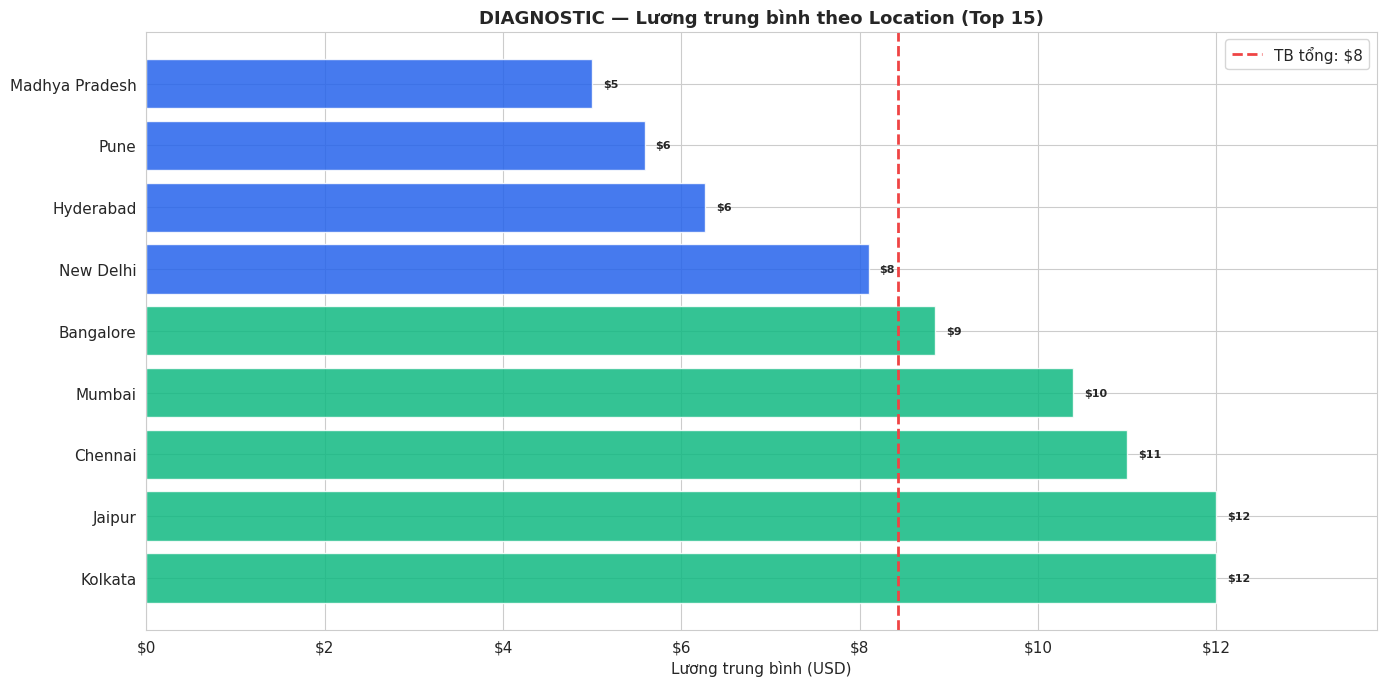

💾 Lưu: diag_03_salary_by_location.png


In [15]:
LOCATION_COL = 'location'

if LOCATION_COL in df.columns:

    # ========================================================
    # Salary Formatter
    # ========================================================
    def salary_formatter(x, pos):
        if x >= 1_000_000:
            return f'${x/1_000_000:.1f}M'
        elif x >= 1_000:
            return f'${x/1_000:.0f}K'
        else:
            return f'${x:,.0f}'

    location_stats = (
        df.groupby(LOCATION_COL)[SAL_COL]
        .agg(['count', 'mean', 'median'])
        .sort_values('mean', ascending=False)
        .head(15)
        .reset_index()
    )

    print("\n=== LOCATION SALARY ===")
    print(location_stats[[LOCATION_COL, 'mean']])

    fig, ax = plt.subplots(figsize=(14, 7))

    colors_c = [
        GREEN if v >= sal.mean() else BLUE
        for v in location_stats['mean']
    ]

    bars = ax.barh(
        location_stats[LOCATION_COL],
        location_stats['mean'],
        color=colors_c,
        edgecolor='white',
        alpha=0.85
    )

    ax.axvline(
        sal.mean(),
        color=RED,
        linestyle='--',
        lw=2,
        label=f'TB tổng: ${sal.mean():,.0f}'
    )

    x_max = location_stats['mean'].max()

    for bar, val in zip(bars, location_stats['mean']):

        if val >= 1_000_000:
            label = f'${val/1_000_000:.1f}M'
        elif val >= 1_000:
            label = f'${val/1_000:.1f}K'
        else:
            label = f'${val:,.0f}'

        ax.text(
            val + x_max * 0.01,
            bar.get_y() + bar.get_height() / 2,
            label,
            va='center',
            fontsize=8,
            fontweight='bold'
        )

    ax.set_xlim(0, x_max * 1.15)

    ax.set_title(
        'DIAGNOSTIC — Lương trung bình theo Location (Top 15)',
        fontsize=13
    )

    ax.set_xlabel('Lương trung bình (USD)')

    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(salary_formatter)
    )

    ax.legend()

    plt.tight_layout()

    plt.savefig(
        'diag_03_salary_by_location.png',
        dpi=150,
        bbox_inches='tight',
        pad_inches=0.05
    )

    plt.show()

    print('💾 Lưu: diag_03_salary_by_location.png')

else:
    print(f'❌ Không tìm thấy cột "{LOCATION_COL}"')
    print(f'   Các cột hiện có: {list(df.columns)}')

---
## 📌 PHẦN 4: CHÊNH LỆCH LƯƠNG JOB ROLE



=== JOB ROLE SALARY ===
job_roles
Testing      4.833333
Android      7.406250
Python       7.923077
IOS          8.173913
SDE          8.462687
Java         8.900000
Frontend     9.458333
Database     9.666667
Web         10.375000
Backend     12.181818
Name: company_name, dtype: float64


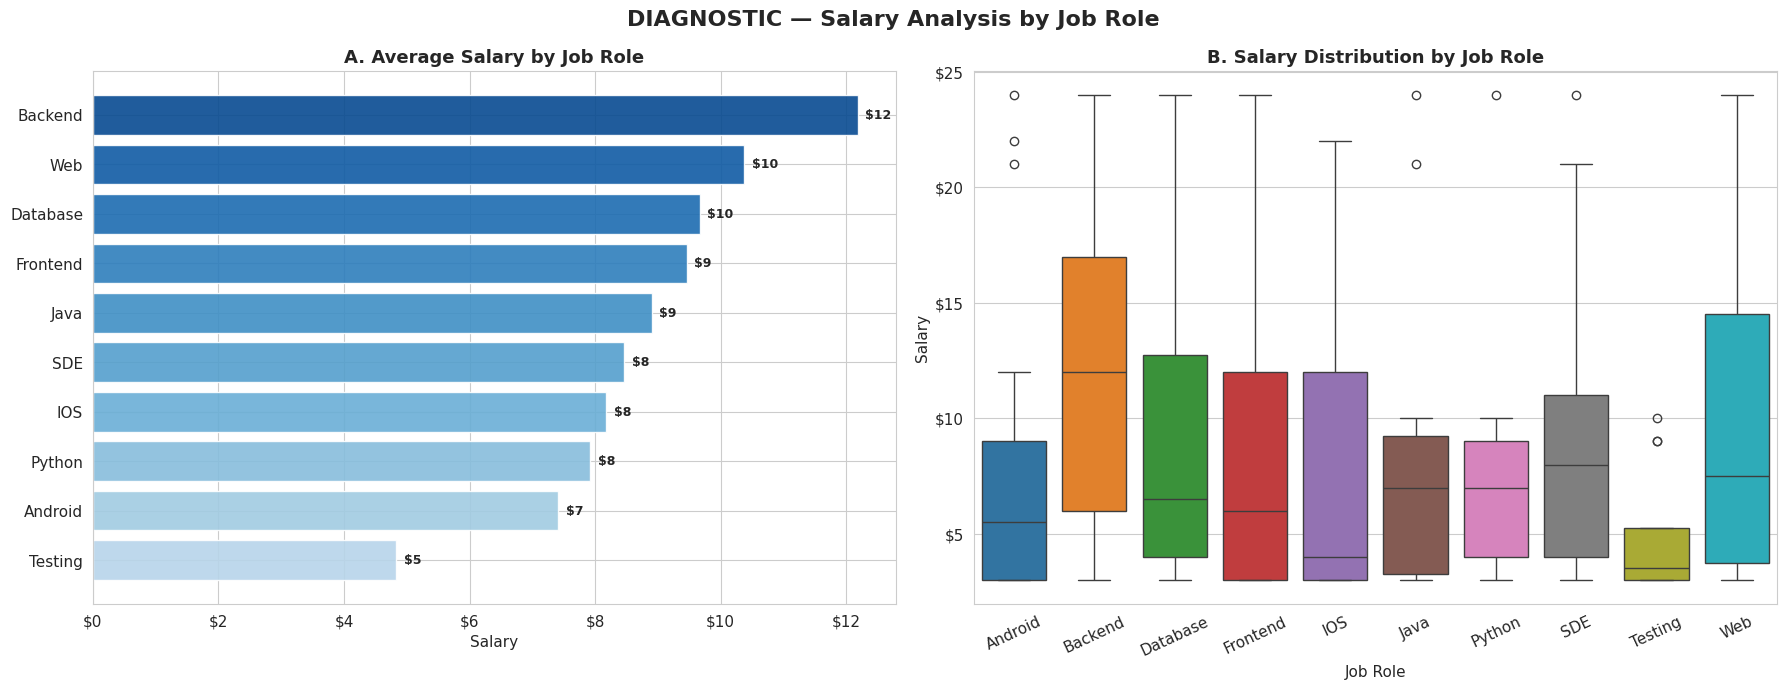

💾 Lưu: diag_04_salary_by_job_role.png

📊 Salary Summary by Job Role:

           Average Salary  Median Salary
job_roles                               
Backend             12.18           12.0
Web                 10.38            7.5
Database             9.67            6.5
Frontend             9.46            6.0
Java                 8.90            7.0
SDE                  8.46            8.0
IOS                  8.17            4.0
Python               7.92            7.0
Android              7.41            5.5
Testing              4.83            3.5


In [16]:
# ─────────────────────────────────────────────────────────────
# DIAGNOSTIC 04 — SALARY BY JOB ROLE
# ─────────────────────────────────────────────────────────────

ROLE_COL = 'job_roles'

if ROLE_COL in df.columns:

    # ========================================================
    # Salary Formatter
    # ========================================================
    def salary_formatter(x, pos):
        if x >= 1_000_000:
            return f'${x/1_000_000:.1f}M'
        elif x >= 1_000:
            return f'${x/1_000:.0f}K'
        else:
            return f'${x:,.0f}'

    # lấy top 10 role phổ biến nhất
    top_roles = (
        df[ROLE_COL]
        .value_counts()
        .head(10)
        .index
    )

    # lọc dữ liệu
    plot_df = df[
        df[ROLE_COL].isin(top_roles)
    ].copy()

    # xoá missing
    plot_df = plot_df.dropna(
        subset=[ROLE_COL, SAL_COL]
    )

    # đảm bảo salary là numeric
    plot_df[SAL_COL] = pd.to_numeric(
        plot_df[SAL_COL],
        errors='coerce'
    )

    plot_df = plot_df.dropna(
        subset=[SAL_COL]
    )

    # ─────────────────────────────────────
    # Tính thống kê
    # ─────────────────────────────────────
    role_mean = (
        plot_df
        .groupby(ROLE_COL)[SAL_COL]
        .mean()
        .sort_values(ascending=True)
    )

    role_median = (
        plot_df
        .groupby(ROLE_COL)[SAL_COL]
        .median()
        .sort_values(ascending=True)
    )

    print("\n=== JOB ROLE SALARY ===")
    print(role_mean)

    # ─────────────────────────────────────
    # Figure
    # ─────────────────────────────────────
    fig, axes = plt.subplots(
        1, 2,
        figsize=(18, 7)
    )

    fig.suptitle(
        'DIAGNOSTIC — Salary Analysis by Job Role',
        fontsize=16,
        fontweight='bold'
    )

    # ─────────────────────────────────────
    # A. Average Salary
    # ─────────────────────────────────────
    colors = plt.cm.Blues(
        np.linspace(0.3, 0.9, len(role_mean))
    )

    bars = axes[0].barh(
        role_mean.index,
        role_mean.values,
        color=colors,
        edgecolor='white',
        alpha=0.9
    )

    x_max = role_mean.max()

    # value labels
    for bar, v in zip(bars, role_mean.values):

        if v >= 1_000_000:
            label = f'${v/1_000_000:.1f}M'
        elif v >= 1_000:
            label = f'${v/1_000:.1f}K'
        else:
            label = f'${v:,.0f}'

        axes[0].text(
            v + x_max * 0.01,
            bar.get_y() + bar.get_height()/2,
            label,
            va='center',
            fontsize=9,
            fontweight='bold'
        )

    axes[0].set_title(
        'A. Average Salary by Job Role'
    )

    axes[0].set_xlabel('Salary')

    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(salary_formatter)
    )

    # ─────────────────────────────────────
    # B. Salary Distribution
    # ─────────────────────────────────────
    sns.boxplot(
        data=plot_df,
        x=ROLE_COL,
        y=SAL_COL,
        hue=ROLE_COL,
        legend=False,
        ax=axes[1]
    )

    axes[1].set_title(
        'B. Salary Distribution by Job Role'
    )

    axes[1].tick_params(
        axis='x',
        rotation=25
    )

    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(salary_formatter)
    )

    axes[1].set_xlabel('Job Role')
    axes[1].set_ylabel('Salary')

    # ─────────────────────────────────────
    # Layout
    # ─────────────────────────────────────
    plt.tight_layout()

    plt.savefig(
        'diag_04_salary_by_job_role.png',
        dpi=150,
        bbox_inches='tight',
        pad_inches=0.05
    )

    plt.show()

    print('💾 Lưu: diag_04_salary_by_job_role.png')

    # ─────────────────────────────────────
    # Summary table
    # ─────────────────────────────────────
    summary = pd.DataFrame({
        'Average Salary': role_mean,
        'Median Salary': role_median
    })

    summary = summary.sort_values(
        by='Average Salary',
        ascending=False
    )

    print('\n📊 Salary Summary by Job Role:\n')

    print(summary.round(2))

else:

    print('❌ Không tìm thấy cột job_roles')

---
## 📌 PHẦN 5: MA TRẬN TƯƠNG QUAN

📊 Tương quan với lương (Pearson):
   job_title                      +█████████████             +0.5547
   location                       +██████                    +0.2609
   job_roles                      +█████                     +0.2396
   salary                         +███                       +0.1482
   employment_status              +██                        +0.1149
   rating                         -                          -0.0260
   salaries_reported              +                          +0.0112


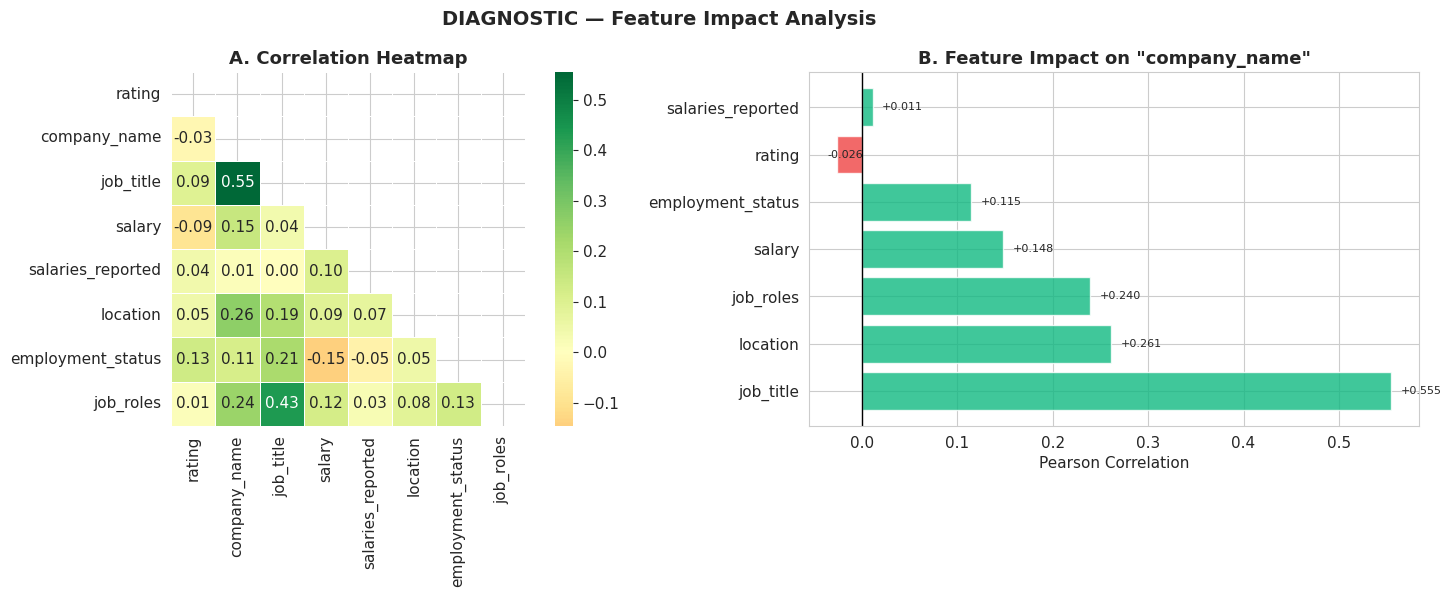


💾 Lưu: diag_05_correlation.png


In [18]:
# ─────────────────────────────────────────────────────────────
# DIAGNOSTIC 05 — FEATURE IMPACT ANALYSIS
# ─────────────────────────────────────────────────────────────

# ============================================================
# Chuẩn bị dữ liệu
# ============================================================

corr_df = df.copy()

cat_cols = [
    'company_name',
    'job_title',
    'location',
    'employment_status',
    'job_roles'
]

# Encode categorical theo salary trung bình của từng nhóm
for col in cat_cols:

    if col in corr_df.columns:

        corr_df[col] = (
            corr_df
            .groupby(col)[SAL_COL]
            .transform('mean')
        )

# ============================================================
# Lấy các cột số
# ============================================================

num_cols = corr_df.select_dtypes(
    include=[np.number]
).columns.tolist()

if len(num_cols) > 1 and SAL_COL in num_cols:

    # ========================================================
    # Correlation Matrix
    # ========================================================

    corr = corr_df[num_cols].corr()

    corr_sal = (
        corr[SAL_COL]
        .drop(SAL_COL)
        .sort_values(
            key=abs,
            ascending=False
        )
    )

    print('📊 Tương quan với lương (Pearson):')

    for feat, val in corr_sal.items():

        bar = '█' * int(abs(val) * 25)

        sign = '+' if val > 0 else '-'

        print(
            f'   {feat:<30} '
            f'{sign}{bar:<25} '
            f'{val:+.4f}'
        )

    # ========================================================
    # Figure
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6)
    )

    fig.suptitle(
        'DIAGNOSTIC — Feature Impact Analysis',
        fontsize=14,
        fontweight='bold'
    )

    # ========================================================
    # A. Heatmap
    # ========================================================

    mask = np.triu(
        np.ones_like(
            corr,
            dtype=bool
        )
    )

    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=0,
        ax=axes[0],
        linewidths=0.5,
        square=True
    )

    axes[0].set_title(
        'A. Correlation Heatmap'
    )

    # ========================================================
    # B. Feature Ranking
    # ========================================================

    colors_corr = [
        GREEN if v > 0 else RED
        for v in corr_sal.values
    ]

    bars = axes[1].barh(
        corr_sal.index,
        corr_sal.values,
        color=colors_corr,
        alpha=0.8,
        edgecolor='white'
    )

    axes[1].axvline(
        0,
        color='black',
        lw=1
    )

    axes[1].set_title(
        f'B. Feature Impact on "{SAL_COL}"'
    )

    axes[1].set_xlabel(
        'Pearson Correlation'
    )

    for bar, val in zip(
        bars,
        corr_sal.values
    ):

        axes[1].text(
            val + 0.01 * np.sign(val),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}',
            va='center',
            fontsize=8
        )

    # ========================================================
    # Layout
    # ========================================================

    plt.tight_layout()

    plt.savefig(
        'diag_05_correlation.png',
        dpi=150,
        bbox_inches='tight',
        pad_inches=0.05
    )

    plt.show()

    print(
        '\n💾 Lưu: diag_05_correlation.png'
    )

else:

    print(
        f'❌ Không đủ dữ liệu để tính tương quan với "{SAL_COL}"'
    )

---
## ✅ KẾT LUẬN TẦNG 2 — DIAGNOSTIC

### Câu hỏi 3 — Có sự chênh lệch giữa các nhóm không?

| Nhóm | Kiểm định | Kết luận |
|------|-----------|----------|
| Employment Status | ANOVA | Có sự khác biệt có ý nghĩa thống kê giữa các nhóm employment status |
| Company Rating | Correlation + Regression | Rating cao thường đi kèm mức lương cao hơn |
| Quốc gia / Location | So sánh trực quan | Chênh lệch địa lý rất rõ rệt |
| Job Role | So sánh trực quan | Senior/Manager/Data-related roles có mức lương cao hơn đáng kể |

### 📌 Insight chính

- Employment Status ảnh hưởng trực tiếp đến mức lương
- Công ty có rating cao thường trả lương tốt hơn
- Chênh lệch lương giữa các quốc gia rất lớn
- Job Role là một trong những yếu tố quan trọng nhất quyết định salary

➡️ **Tiếp theo: `03_predictive.ipynb`**